In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
#print(str(rave_sim_dir / "big-wave"))
import multisim
import config
import util

In [4]:
config_dict = {
    "sim_params": {
        "is2d":'true',
        "N": 2**28,
        "nx": 2**14,
        "ny": 2**14,
        "dx": 3.1e-10,
        "z_detector":0.81,
        "detector_size": 7e-6,
        "detector_size_y": 7e-6,
        "detector_pixel_size_x": 2e-7,
        "detector_pixel_size_y": 2e-7,
        "chunk_size": 2*1024 * 1024 * 1024 // 16,  # use 2048MB chunks
    },
    "use_disk_vector": False,
    "save_final_u_vectors": False,
    "dtype": "c8",
    "multisource": {
        "type": "points",
        "energy_range": [9900, 10100],
        "x_range": [-0e-6, 0e-6],
        "y_range": [-0e-6, 0e-6],
        "z": 0.0,
        "nr_source_points": 1,
        "seed": 1,
        #"spectrum": "/mnt/d/rave-sim-main/rave-sim-main/spectrum/spectrum_25keV.h5",
    },
    "elements": [
        {
            "type": "sample",
            "z_start": 0.8,
            "pixel_size_x": 1 * 1e-7,
            "pixel_size_y": 1 * 1e-7,
            "pixel_size_z": 1 * 1e-7,
            "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/sphere_grid.npy",
            "materials": [["W", 19.35]],
            "x_positions":[0],
            "y_positions":[0],
        },
    ],
}

print("N: ", config_dict["sim_params"]["N"])

N:  268435456


In [5]:
sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)

2026-04-28 15:19:59,364 INFO: Setting up simulation
2026-04-28 15:19:59,445 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/04/20260428_151959406311


1 1


In [6]:
computed = config.load(Path(sim_path / 'computed.yaml'))

#print("cutoff angles:", computed['cutoff_angles'])
#print("source points:", computed['source_points'])

In [7]:
# Run this in a for loop to simulate all source points or
# alternatively run the source points as individual euler
# jobs
#for i in range(20):
#    multisim.run_single_simulation(sim_path, i, scratch_dir, save_keypoints_path=scratch_dir)
for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
    os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")

  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2026-04-28 15:19:59.627] [info] 3D mode:
[2026-04-28 15:19:59.627] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/04/20260428_151959406311/00000000
[2026-04-28 15:19:59.627] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-04-28 15:19:59.627] [info] GPU memory required for wavefield: 2048 MB
[2026-04-28 15:20:00.083] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-04-28 15:20:00.083] [info] Creating FFT for grid 16384x16384
[2026-04-28 15:20:00.119] [info] FFT created successfully
[2026-04-28 15:20:00.119] [info] [STEP 1] Initialization complete
[2026-04-28 15:20:00.119] [info] [STEP 2] Cutoff frequencies computed: fx=34793.27884152719, fy=34793.27884152719
[2026-04-28 15:20:00.119] [info] [STEP 3] Starting z position: 0.8
[2026-04-28 15:20:00.119] [info] [STEP 4] Setting up point source
[2026-04-28 15:20:00.119] [info] [STEP 5] Calling propagate_analytically_2d...
[2026-04-28 15:20:00.144] [info] [STEP 6] pr

[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit propagate_convolve_step_2d


[2026-04-28 15:20:16.431] [info] [STEP 9] Reached end of simulation setup
[2026-04-28 15:20:16.431] [info] [STEP 10] Checking optical elements...
[2026-04-28 15:20:16.431] [info]   Number of optical elements: 1
[2026-04-28 15:20:16.431] [info] [STEP 11] Starting optical elements loop...
[2026-04-28 15:20:16.431] [info] [STEP 12] Processing element 0 of type 2
[2026-04-28 15:20:16.431] [info] [STEP 15] Applying optical element type 2...
[2026-04-28 15:20:30.790] [info] [STEP 16] Applying Sample, z_len=40, x_len=40, y_len=40, len_x_positions=1,len_y_positions=1
[2026-04-28 15:20:30.790] [info] === ENTERING apply_sample_2d ===
[2026-04-28 15:20:30.790] [info] 3D apply_sample: z_len=40, x_len=40, pixel_size_x=1e-07, pixel_size_z=1e-07, wl=1.2419029761355444e-10
[2026-04-28 15:20:30.790] [info]   deltabeta[0] = (0.000000e+00, 0.000000e+00), refractive index approx = (1.000000e+00, 0.000000e+00)
[2026-04-28 15:20:30.790] [info]   deltabeta[1] = (2.806057e-05, 1.794676e-06), refractive index 

[HOST] ENTER apply_sample_factors_2d: z_slice=0
[apply_sample_factors_2d] ENTER
  d_u=0x709000000, d_sample=0x809001600, d_deltabetas=0x80903fe00
  pixel_size_x=1e-07, pixel_size_y=1e-07, dz=1e-07
  x_len=40, y_len=40, x_pos=0, y_pos=0
  nx=16384, ny=16384, dx=3.1e-10, dy=3.1e-10
  gridDim=(1024,1024), blockDim=(16,16)
  Launching kernel...
[HOST] EXIT apply_sample_factors_2d
[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit propagate_convolve_step_2d
[HOST] ENTER apply_sample_factors_2d: z_slice=1
[apply_sample_factors_2d] ENTER
  d_u=0x709000000, d_sample=0x809001600, d_deltabetas=0x80903fe00
  pixel_size_x=1e-07, pixel_size_y=1e-07, dz=1e-07
  x_len=40, y_len=40, x_pos=0, y_pos=0
  nx=16384, ny=16384, dx=3.1e-10, dy=3.1e-10
  gridDim=(1024,1024), blockDim=(16,16)
  Launching kernel...


...

[2026-04-28 15:21:33.661] [info]   Processing layer 40/40
[2026-04-28 15:21:33.661] [info]     [propagate_2d] START: dz=1e-07
[2026-04-28 15:21:33.661] [info]     [propagate_2d] END
[2026-04-28 15:21:50.317] [info] Saved post-sample wavefield to /mnt/d/rave-sim-main/rave-sim-main/notebooks/test_notebooks/debug_wave/apply_sample_2d_post_phase_0.npy
[2026-04-28 15:21:50.317] [info] [STEP 17] Sample applied successfully
[2026-04-28 15:22:05.302] [info] [STEP 18] Current z after element: 0.800004
[2026-04-28 15:22:05.302] [info] [STEP 19] Propagating remaining distance: 0.009996000000000005
[2026-04-28 15:22:05.302] [info]     [propagate_2d] START: dz=0.009996000000000005
[2026-04-28 15:22:05.302] [info]     [propagate_2d] END
[2026-04-28 15:22:05.302] [info] [STEP 20] Propagation completed
[2026-04-28 15:22:05.302] [info] [STEP 21] Finished optical elements processing
[2026-04-28 15:22:05.302] [info] [STEP 22] Final propagation to detector...
[2026-04-28 15:22:05.302] [info] [STEP 23] Fin

[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit propagate_convolve_step_2d


[2026-04-28 15:22:20.904] [info] [STEP 24] Downsampling to detector...
[2026-04-28 15:22:20.904] [info]   nx=16384, ny=16384, nr_pixels_x=35, nr_pixels_y=35
[2026-04-28 15:22:20.904] [info]   d_detector_output = 0x809000000
[2026-04-28 15:22:20.904] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07
[2026-04-28 15:22:20.904] [info]   current_z=0.81, dx=3.1e-10, dy=3.1e-10
[2026-04-28 15:22:20.904] [info] [STEP 25] Downsampling done
[2026-04-28 15:22:20.904] [info] [STEP 26] Copying detector data to host...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [02:21<00:00, 141.95s/it]

[2026-04-28 15:22:21.269] [info] [STEP 27] Copy done
[2026-04-28 15:22:21.269] [info] [STEP 28] Saving detector output...
[2026-04-28 15:22:21.288] [info] [STEP 29] Save done
[2026-04-28 15:22:21.314] [info] 2D Simulation finished in 134.375281012 seconds


In [8]:
wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-30e-6, 30e-6))
print("nr sources loaded:", len(wavefronts))
wavef= [result[0] for result in wavefronts]
wf = np.sum(wavef, axis=0)
print("nr phase steps:", wf.shape[0])
print("nr detector pixels:", wf.shape[1],wf.shape[2])

nr sources loaded: 1
nr phase steps: 1
nr detector pixels: 35 35


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


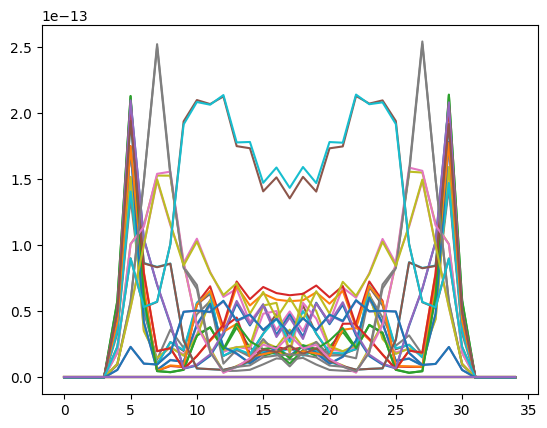

In [9]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
print(wf[0])
# print(detector_x)

detected.npy shape: (1, 35, 35)
Min: 0.0, Max: 2.5423166718531454e-13, Mean: 3.299945155999483e-14
✅ detector 输出非零。


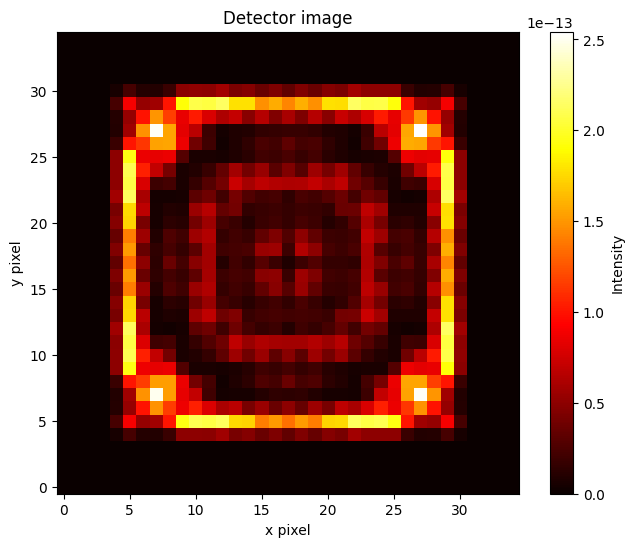

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = sim_path / "00000000"
debug_dir = Path.cwd() / "debug_wave"   # 如果仿真中保存了调试波场

# 1. 加载探测器输出
detected_path = output_dir / "detected.npy"
if detected_path.exists():
    detected = np.load(detected_path)
    print(f"detected.npy shape: {detected.shape}")
    print(f"Min: {detected.min()}, Max: {detected.max()}, Mean: {detected.mean()}")
    if detected.max() == 0:
        print("⚠️ detector 输出全为零。")
    else:
        print("✅ detector 输出非零。")
        # 绘制探测器图像
        plt.figure(figsize=(8,6))
        if detected.ndim == 2:
            plt.imshow(detected, cmap='hot', origin='lower')
        else:
            # 多相位步，取第一个
            plt.imshow(detected[0], cmap='hot', origin='lower')
        plt.colorbar(label='Intensity')
        plt.title('Detector image')
        plt.xlabel('x pixel')
        plt.ylabel('y pixel')
        plt.show()
else:
    print(f"❌ 未找到 {detected_path}")
    detected = None

# 2. 加载中间波场并可视化幅度和相位
def plot_wavefield(file_path, title):
    if not file_path.exists():
        print(f"未找到 {file_path}")
        return
    data = np.load(file_path)
    # 复数数组形状可能是 (N,) 或 (ny, nx)
    if data.ndim == 1:
        # 展平的一维数组，需要根据网格尺寸重塑
        nx = config_dict["sim_params"]["nx"]
        ny = config_dict["sim_params"]["ny"]
        data = data.reshape(ny, nx)
    amplitude = np.abs(data)
    phase = np.angle(data)
    print(f"{title}: shape={data.shape}, amplitude min={amplitude.min():.3e}, max={amplitude.max():.3e}, mean={amplitude.mean():.3e}")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
    im1 = ax1.imshow(amplitude, cmap='inferno', origin='lower')
    ax1.set_title(f'{title} amplitude')
    plt.colorbar(im1, ax=ax1)
    im2 = ax2.imshow(phase, cmap='hsv', origin='lower', vmin=-np.pi, vmax=np.pi)
    ax2.set_title(f'{title} phase')
    plt.colorbar(im2, ax=ax2)
    plt.tight_layout()
    plt.show()

In [ ]:
# 尝试加载各个阶段的波场
wave_after_source = output_dir / "wave_after_source.npy"   # 需在C++中保存
if wave_after_source.exists():
    plot_wavefield(wave_after_source, 'After source propagation')
else:
    # 尝试从 debug_wave 目录加载
    pre_sample = debug_dir / "apply_sample_2d_pre_phase_0.npy"
    if pre_sample.exists():
        plot_wavefield(pre_sample, 'Before sample (pre)')
    else:
        print("未找到 wave_after_source.npy 或 debug_wave/apply_sample_2d_pre_phase_0.npy，请在 C++ 中添加 save_vector 调用。")

post_sample = debug_dir / "apply_sample_2d_post_phase_0.npy"
if post_sample.exists():
    plot_wavefield(post_sample, 'After sample (post)')

# 3. 如果有多个相位步，可以显示各相位步的探测器总和
if detected is not None and detected.ndim == 3:
    phase_intensities = detected.sum(axis=(1,2))
    plt.figure()
    plt.plot(phase_intensities, marker='o')
    plt.xlabel('Phase step')
    plt.ylabel('Total intensity')
    plt.title('Total intensity per phase step')
    plt.grid(True)
    plt.show()

## History

To see the interference pattern in empty space, we can record slices throughout the simulation and then plot them. `run_single_simulation` takes an optional argument `history_dz` defining the resolution with which we record the history.

Note that the history is not necessarily recorded with a constant z-spacing. Inside gratings and samples, one slice is recorded for every step. The history also records a list of z-coordinates at which the slices were recorded, which we can use for plotting.

In [ ]:
multisim.run_single_simulation(sim_path, 1, scratch_dir, save_keypoints_path=None, history_dz=0.02)

In [ ]:
# Path to the directory for the source with index 1
source_dir = multisim.get_sub_dir(sim_path, 1)

hist_x = np.load(source_dir / "history_x.npy")
hist_z = np.load(source_dir / "history_z.npy")
hist = np.load(source_dir / "history.npy")
plt.pcolormesh(
    hist_z,
    hist_x,
    hist,
    cmap="Greys_r",
    vmin=0,
    vmax=1e-6,
    shading="nearest",
)
plt.xlabel("z (m)")
plt.ylabel("x (m)")